In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
DATA_DIR = r"/content/drive/MyDrive/BMGT394H - Client/BBB Data Uploads" # change as needed
# loading cleaned datasets
basic_cancel_df = pd.read_excel(f"{DATA_DIR}/basic_cancel_df_cleaned.xlsx")
ab_df = pd.read_excel(f"{DATA_DIR}/ab_df_cleaned.xlsx")
basic_login_df = pd.read_excel(f"{DATA_DIR}/basic_login_df_cleaned.xlsx")
dynamic_seal_df = pd.read_excel(f"{DATA_DIR}/dynamic_seal_df_cleaned.xlsx")
df_merged = pd.read_excel(f"{DATA_DIR}/df_merged_cleaned.xlsx")
reviews_df_2023_2026 = pd.read_excel(f"{DATA_DIR}/reviews_df_cleaned 2023-2026.xlsx")
complaints_df_2023_2026 = pd.read_excel(f"{DATA_DIR}/complaints_df_cleaned 2023-2026.xlsx")


Mounted at /content/drive


Part 1. For this template, 2025 is the prediction dataset, but in the future this part would be the year you want to predict.

In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

# Make sure dates are datetime
df_merged['Date Joined'] = pd.to_datetime(df_merged['Date Joined'], errors='coerce')
df_merged['Drop Date'] = pd.to_datetime(df_merged['Drop Date'], errors='coerce')

# Define time windows
cutoff_train = pd.to_datetime("2024-12-31")
start_2025 = pd.to_datetime("2025-01-01")
end_2025 = pd.to_datetime("2025-12-31")

# Create target: did business drop in 2025?
df_merged['Dropped_2025'] = (
    (df_merged['Drop Date'] >= start_2025) &
    (df_merged['Drop Date'] <= end_2025)
).astype(int)

Part 2: Here is the past dataset (2022-2024), but can be edited to any range of years.::

In [6]:
# Keep only businesses that existed during 2022–2024 window
start_2022 = pd.to_datetime("2022-01-01")

model_df = df_merged[
    (df_merged['Date Joined'] <= cutoff_train) &   # joined before end of 2024
    (df_merged['Date Joined'] >= start_2022)       # joined after start of 2022
].copy()

Part 3: The Logistic Regression Model

In [7]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Build features from model_df
model_df['Tenure_2024'] = (cutoff_train - model_df['Date Joined']).dt.days

model_df['Click Rate'] = model_df['Clicks'] / model_df['Tenure_2024']
model_df['Click Rate'] = model_df['Click Rate'].replace([np.inf, -np.inf], np.nan)

# One-hot encode TOB
tob_dummies = pd.get_dummies(model_df['Primary TOB'], prefix='Primary_TOB', drop_first=True)

# Build X and y fresh from model_df
X = pd.concat([model_df[['Tenure_2024', 'Click Rate']], tob_dummies], axis=1)
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

y = model_df['Dropped_2025']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train logistic regression
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_scaled, y)

# Predict probability of dropping in 2025
model_df['Pred_2025_Prob'] = model.predict_proba(X_scaled)[:, 1]

# Convert probabilities to yes/no using threshold
threshold = 0.5
model_df['Pred_Dropped_2025'] = (model_df['Pred_2025_Prob'] >= threshold).astype(int)

Part 4: Evaluation of the Model

In [8]:
# Evaluate
accuracy = accuracy_score(model_df['Dropped_2025'], model_df['Pred_Dropped_2025'])
auc = roc_auc_score(model_df['Dropped_2025'], model_df['Pred_2025_Prob'])

# Number predicted to churn
num_predicted_churn = model_df['Pred_Dropped_2025'].sum()
print(f"Number of businesses predicted to churn: {num_predicted_churn}")

print(f"Accuracy on 2025 prediction: {accuracy:.3f}")
print(f"AUC on 2025 prediction: {auc:.3f}")

# Show highest-risk businesses
print("\nTop predicted 2025 drop risks:")
print(
    model_df[['Business', 'Dropped_2025', 'Pred_2025_Prob']]
    .sort_values(by='Pred_2025_Prob', ascending=False)
    .head(20)
)

Number of businesses predicted to churn: 535
Accuracy on 2025 prediction: 0.609
AUC on 2025 prediction: 0.732

Top predicted 2025 drop risks:
                                Business  Dropped_2025  Pred_2025_Prob
3943              North Starr Group, LLC             1        0.853740
3931  The Big Playground Creative Studio             1        0.850023
3923       Wander Lux Transportation LLC             1        0.826068
3292                           Party 360             1        0.818535
3922                       CBTC Partners             1        0.816613
3969                     Libre Group LLC             1        0.814675
3986         Taylor - Rogers Enterprises             1        0.808765
3870          Construction Phase 1.5 LLC             0        0.798599
3962  Architectural Building Surveys LLC             1        0.794421
2339            Hazelwood Inn Restaurant             0        0.793532
3867              Out the Box Krafts LLC             0        0.792308
3083  

Part 5: Visualization of the Model

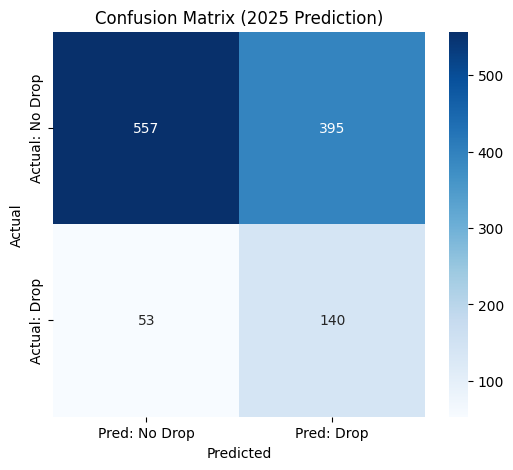

Accuracy:  0.609
Precision: 0.262
Recall:    0.725

Predicted to churn: 535
Accuracy: 0.6087336244541485
Precision: 0.2616822429906542
Recall: 0.7253886010362695


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# define labels
y_true = model_df['Dropped_2025']
y_pred = model_df['Pred_Dropped_2025']

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No Drop', 'Pred: Drop'],
            yticklabels=['Actual: No Drop', 'Actual: Drop'])

plt.title('Confusion Matrix (2025 Prediction)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")

# number predicted to churn
num_pred_churn = y_pred.sum()
print(f"\nPredicted to churn: {num_pred_churn}")

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))